In [94]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

In [ ]:
from torchvision import transforms
Akbar afterDataData memory
transform = transforms.Compose([transforms.Resize((128,128)),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(30),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]),
                                ]) #(converting to tensor and doing data augmentation)

In [96]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [97]:
dataset = ImageFolder('/kaggle/input/datasets/jessicali9530/caltech256/256_ObjectCategories', transform=transform)

In [98]:
train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size
train_data,test_data = random_split(dataset, [train_size,test_size])

In [ ]:
train_loader = DataLoader(train_data , batch_size = 64 , shuffle = True, pin_memory = True) 
test_loader = DataLoader(test_data , batch_size = 64 , shuffle= False , pin_memory = True)

In [100]:
class MyCNN(nn.Module):

    def __init__(self,input_features):
        super().__init__()


        self.features = nn.Sequential(nn.Conv2d(input_features , 64 , kernel_size = 3 , padding = "same"),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(),
                                       
                                      nn.Conv2d(64 , 64 , kernel_size = 3 , padding = "same"),
                                      nn.BatchNorm2d(64),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size = 2, stride = 2),
                                      
                                      nn.Conv2d(64,128 , kernel_size = 3, padding = "same"),
                                      nn.BatchNorm2d(128),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size = 2 , stride = 2),
                                      
                                      nn.Conv2d(128,256, kernel_size = 3 , padding = "same"),
                                      nn.BatchNorm2d(256), 
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size = 2 , stride = 2),
                                      
                                      nn.Conv2d(256,256, kernel_size = 3 , padding = "same"),
                                      nn.BatchNorm2d(256),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size = 2 , stride = 2))
        self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(8*8*256,4096),
              nn.ReLU(),
              nn.Dropout(p=0.5),
              nn.Linear(4096,1024),
              nn.ReLU(),
              nn.Dropout(p=0.5),
              nn.Linear(1024,257)
          )



    def forward(self,x):
          x = self.features(x)
          x = self.classifier(x)


          return x

In [101]:
learning_rate = 0.01
epochs = 50

In [102]:
model = MyCNN(3)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = learning_rate , weight_decay = 1e-4)

In [103]:
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features , batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        out = model(batch_features)
        loss = criterion(out,batch_labels)


        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch:{epoch+1}, Loss:{avg_loss}')

Epoch:1, Loss:5.308003433068178
Epoch:2, Loss:4.9224745947138135
Epoch:3, Loss:4.646334735282719
Epoch:4, Loss:4.434026619784203
Epoch:5, Loss:4.256887502520887
Epoch:6, Loss:4.104881315256224
Epoch:7, Loss:3.9600628754488794
Epoch:8, Loss:3.831422582930124
Epoch:9, Loss:3.7146418206685516
Epoch:10, Loss:3.6095234488693912
Epoch:11, Loss:3.5100727977702886
Epoch:12, Loss:3.4174260732088015
Epoch:13, Loss:3.33629386356543
Epoch:14, Loss:3.2448246055732506
Epoch:15, Loss:3.1646824262783357
Epoch:16, Loss:3.0825292808891276
Epoch:17, Loss:3.0198731391299174
Epoch:18, Loss:2.955288873328864
Epoch:19, Loss:2.8955381333672348
Epoch:20, Loss:2.8327275380764556
Epoch:21, Loss:2.784021058842034
Epoch:22, Loss:2.7149722345815315
Epoch:23, Loss:2.678321520902469
Epoch:24, Loss:2.6135425813515565
Epoch:25, Loss:2.5724909924962813
Epoch:26, Loss:2.528554886190449
Epoch:27, Loss:2.4760973394383963
Epoch:28, Loss:2.438059555955095
Epoch:29, Loss:2.376473536068092
Epoch:30, Loss:2.351869176635543
Epoc

In [ ]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features,batch_labels in test_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)


        outputs = model(batch_features)
        _,predicted = torch.max(outputs,1) #contains the index of the maximum value
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print((correct/total)*100)

40.721986278993796


In [106]:
print(model.features[-4]._forward_hooks)
print(model.features[-4]._backward_hooks)

OrderedDict()
OrderedDict()


In [117]:
model.features[-4]._forward_hooks.clear()
model.features[-4]._backward_hooks.clear()

In [118]:
print(model.features[-4]._forward_hooks)
print(model.features[-4]._backward_hooks)

OrderedDict()
OrderedDict()


In [ ]:
import numpy as np
import cv2

saved_activations = None
saved_gradients = None

def save_activations(module,input,output):
    global saved_activations
    saved_activations = output

def save_gradients(module,grad_input,grad_output):
    global saved_gradients
    saved_gradients = grad_output[0]

model.features[-4].register_forward_hook(save_activations) #to extract out the activations from that layer
model.features[-4].register_full_backward_hook(save_gradients) #to extract out the gradients from that layer

In [120]:
print(model.features[-4]._forward_hooks)
print(model.features[-4]._backward_hooks)

OrderedDict({43: <function save_activations at 0x793ebc0c6980>})
OrderedDict({44: <function save_gradients at 0x793ebc0c6d40>})


In [ ]:
def get_gradcam(image_tensor):
    
    
    model.eval()
    image_tensor = image_tensor.detach().clone() #
    image_tensor.requires_grad_(True)
    output = model(image_tensor)
    predicted_class = output.argmax(dim=1).item()
    model.zero_grad()
    output[0,predicted_class].backward() #calculates gradients with respect to logits of the predicted class and not loss

    print(saved_gradients)
    print(saved_activations)
    print(img.requires_grad)
    channel_importance = saved_gradients.mean(dim=(2,3)).squeeze() #(batch_size,channels,height,width)->(1,256)->(256) #calculating (alpha)_k
    activation_maps = saved_activations.squeeze(). #calculating A_k

    heatmap = torch.zeros(16,16).to(device)
    for i in range(256):
        heatmap = heatmap + channel_importance[i]*activation_maps[i]


    heatmap = torch.relu(heatmap)

    heatmap = heatmap - heatmap.min()
    heatmap = heatmap/(heatmap.max()+1e-8) #normalization
    heatmap = heatmap.detach().cpu().numpy()
    heatmap = cv2.resize(heatmap , (128,128))
    return heatmap,predicted_class

In [ ]:
def show_gradcam(image_tensor,true_label): 

    heatmap,predicted_class = get_gradcam(image_tensor)
    image = image_tensor.squeeze().cpu().permute(2,1,0).numpy() #matplotlib expects image to be in the form of (height,width,channels) rather than (channels,height,width) thats why permute is used
    image = np.clip(image,0,1) 

    heatmap_coloured = cv2.applyColorMap(np.uint8(255*heatmap),cv2.COLORMAP_JET) #uint8 basically converts images to 8 bit form , open cv expects images in 8 bit form
    heatmap_coloured = cv2.cvtColor(heatmap_coloured , cv2.COLOR_BGR2RGB)
    heatmap_coloured = heatmap_coloured/255.0
    blended = 0.5*image + 0.4*heatmap_coloured
    blended = np.clip(blended , 0 ,1)

    plt.imshow(blended)
    title_color = 'green' if true_label==predicted_class else 'red'
    plt.title(f'True = {dataset.classes[true_label]}\nPred = {dataset.classes[predicted_class]}' )
    plt.axis('off')
    plt.show()

In [123]:
correct_samples = []
incorrect_samples = []

model.eval()
with torch.no_grad():
  for images,labels in test_loader:
        for i in range(len(labels)):
            img = images[i].unsqueeze(0).to(device)
            label = labels[i].item()

            output = model(img)
            pred = output.argmax(dim=1).item()

            if pred == label and len(correct_samples)<4:
                correct_samples.append((img,label))

            elif pred != label and len(incorrect_samples)<4:
                incorrect_samples.append((img,label))


        if len(correct_samples) == 4 and len(incorrect_samples)==4:
            break

correctly classified:
tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00, -5.2701e-03,  0.0000e+00,  ...,  0.0000e+00,
           -7.0288e-03,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [-1.0060e-02,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00, -7.6310e-03],
          [-1.3579e-02,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00, -2.3490e-03]

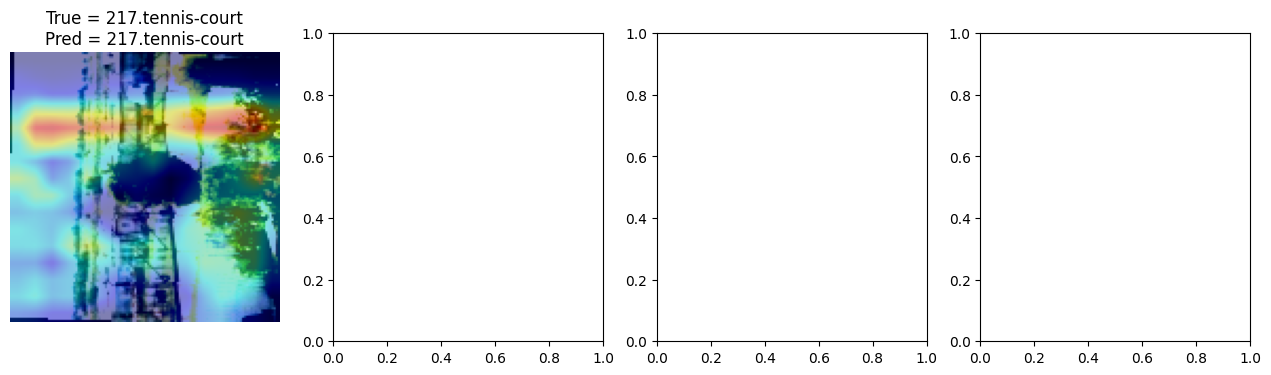

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -9.5472e-03,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00, -1.2165e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00, -1.0210e-03, -1.2547e-02,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  7.3666e-04, -4.1916e-05,  ...,  1.4263e-03,
            0.0000e+00,  1.0357e-03],
          [ 0.0000e+00,  0.0000e+00,  4.5129e-03,  ...,  0.0000e+00,
            0.0000e+00,  5.6210e-03],
          ...,
     

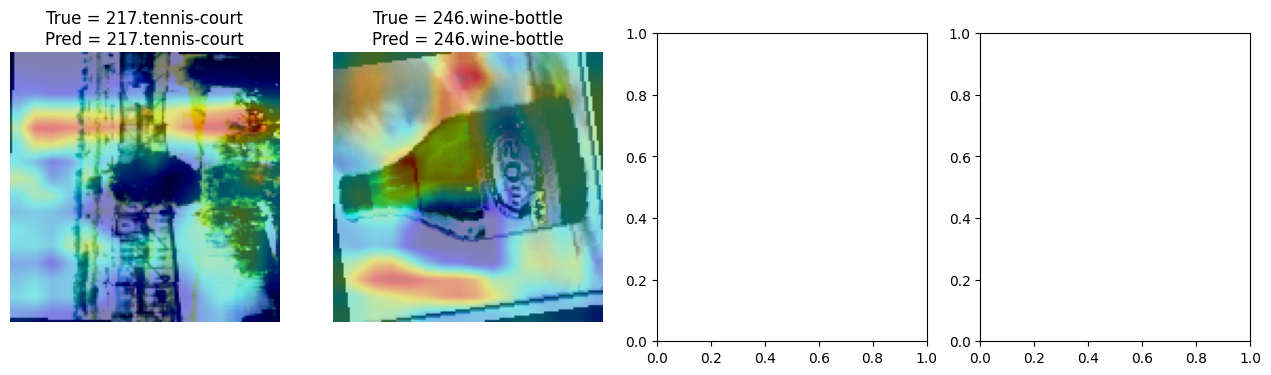

tensor([[[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000, -0.0012,  0.0000,  ...,  0.0016,  0.0018,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0048, -0.0010,  0.0000],
          ...,
          [ 0.0000,  0.0000, -0.0095,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0024,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0018]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0007,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0021],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0002,  0.0005,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0044,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  

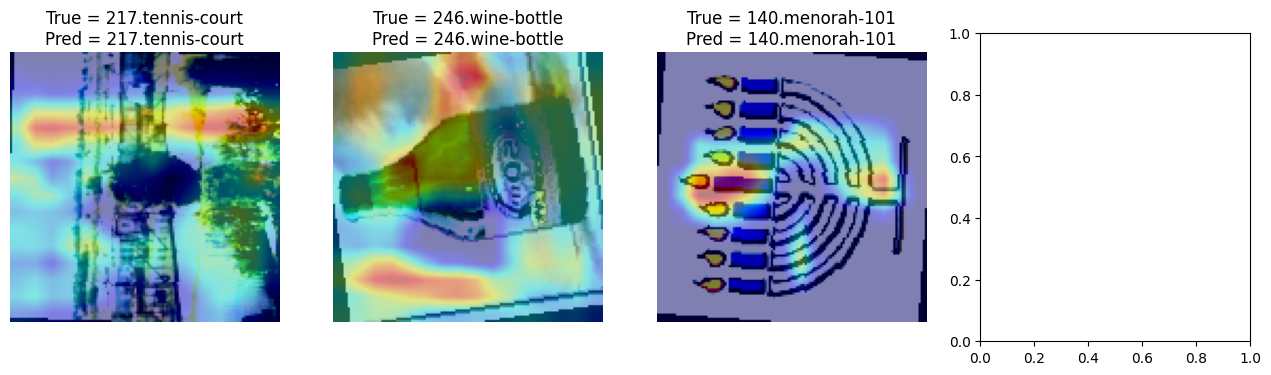

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           -7.7854e-03,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           -2.4787e-03,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [-5.7497e-03,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  1.3661e-02,  9.2596e-03,  ...,  2.4611e-03,
            2.4377e-02,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.0718e-02,
            4.8960e-03,  0.0000e+00],
          ...,
     

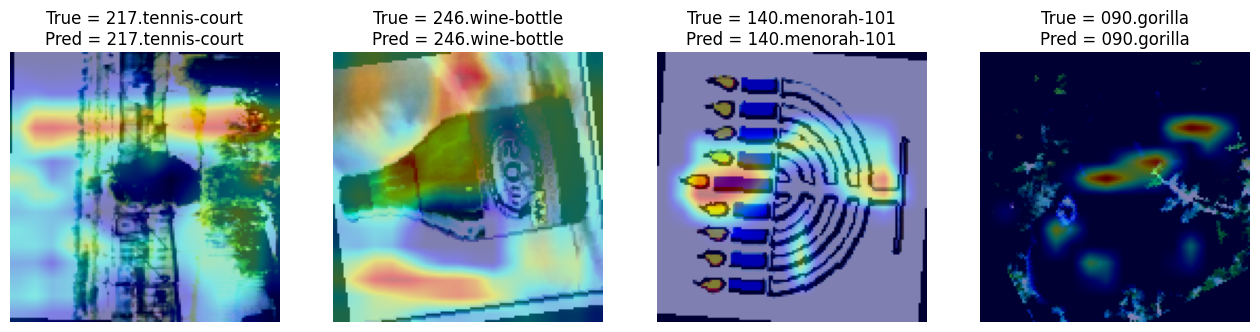

<Figure size 640x480 with 0 Axes>

In [124]:
print("correctly classified:")
fig,axes = plt.subplots(1,4,figsize=(16,4))
for index,(img,label) in enumerate(correct_samples):
    plt.sca(axes[index])
    show_gradcam(img,label)
plt.tight_layout()
plt.show()

incorrectly classified:
tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00, -6.2293e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  2.4633e-03,
            2.2945e-03,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  4.4134e-03,  0.0000e+00,  ...,  1.3902e-03,
           -5.7940e-03,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  7.7782e-04,
           -4.5447e-03,  0.0000e+0

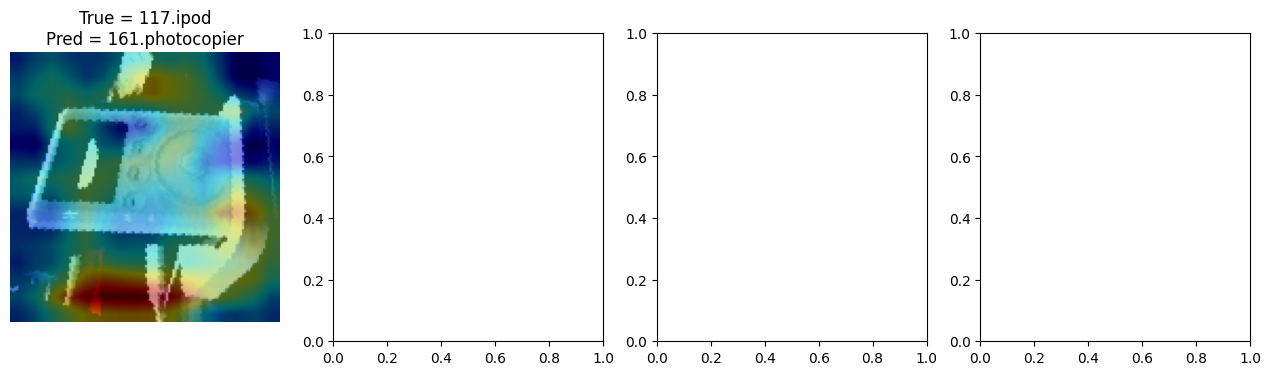

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  2.6328e-03,  0.0000e+00,  ...,  3.5029e-03,
           -8.7915e-05,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           -6.8283e-04,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  6.2544e-04,  0.0000e+00,  ...,  1.1234e-03,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  8.3570e-04]],

         [[ 0.0000e+00, -1.9960e-03,  0.0000e+00,  ...,  0.0000e+00,
           -2.0040e-03,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  2.4454e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
     

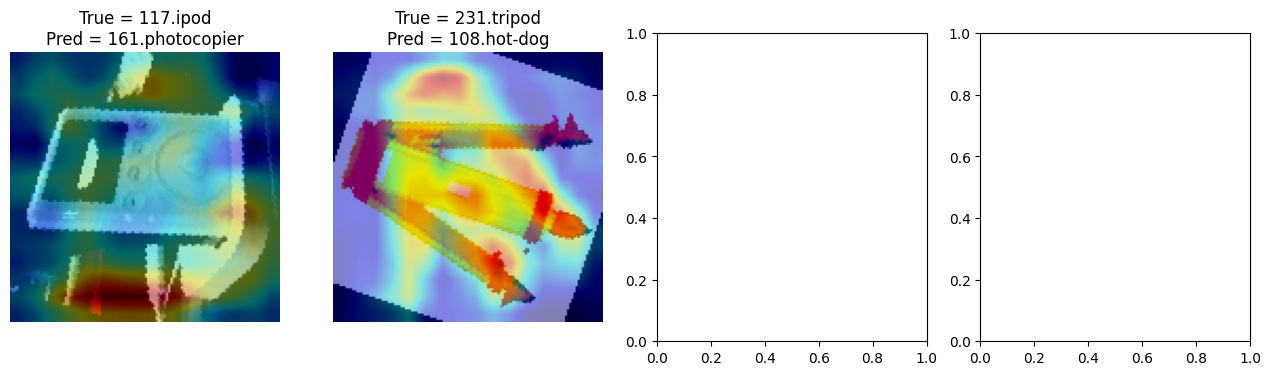

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  8.2074e-04,  0.0000e+00,  ...,  0.0000e+00,
           -2.4414e-03,  0.0000e+00],
          [ 0.0000e+00, -3.5340e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00, -5.2065e-03, -1.2268e-03,  ...,  0.0000e+00,
           -1.0531e-03,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -2.0440e-03,
           -5.7768e-04,  0.0000e+00],
          [ 0.0000e+00,  3.6851e-04,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
     

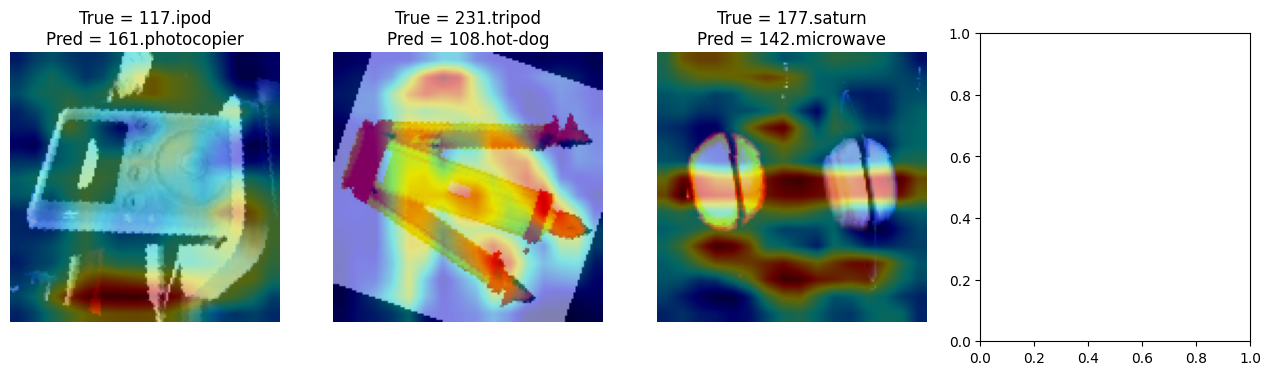

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  3.0273e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.4200e-03,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00, -3.7638e-03]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           -4.7803e-03,  0.0000e+00],
          [ 0.0000e+00,  4.8652e-04,  0.0000e+00,  ...,  1.2881e-03,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  4.8308e-03,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          ...,
     

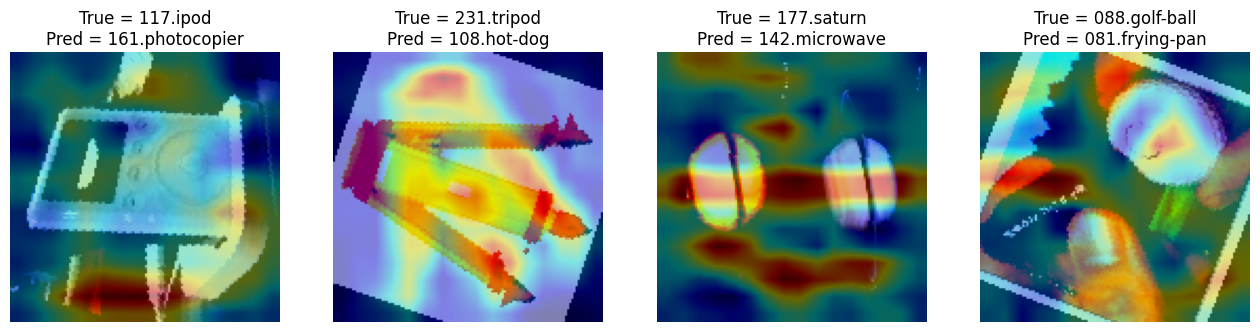

<Figure size 640x480 with 0 Axes>

In [125]:
print("incorrectly classified:")
fig,axes = plt.subplots(1,4,figsize=(16,4))
for index,(img,label) in enumerate(incorrect_samples):
    plt.sca(axes[index])
    show_gradcam(img,label)
plt.tight_layout()
plt.show()